<a href="https://colab.research.google.com/github/SathishKentState/Sathish-Babu-Nuthi_Advanced-Machine-Learning/blob/main/Sathish__Babu__Nuthi__BA74061_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading the Data set

In [ ]:

!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz


import os
if os.path.exists("aclImdb/train/neg"):
    print("Successfully extracted: aclImdb/train/neg exists.")
else:
    print("Error: Extraction failed or directory structure is different.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  49.5M      0  0:00:01  0:00:01 --:--:-- 49.5M
Successfully extracted: aclImdb/train/neg exists.


In [ ]:
import numpy as np


def load_imdb_data(data_dir):
    texts, labels = [], []
    for label_type in ["neg", "pos"]:
        dir_name = os.path.join(data_dir, label_type)
        for fname in os.listdir(dir_name):
            if fname[-4:] == ".txt":
                with open(os.path.join(dir_name, fname), encoding="utf-8") as f:
                    texts.append(f.read())
                labels.append(0 if label_type == "neg" else 1)
    return texts, labels


train_texts, train_labels = load_imdb_data("aclImdb/train")


vectorizer = layers.TextVectorization(
    max_tokens=10000,
    output_mode="int",
    output_sequence_length=150,
)
vectorizer.adapt(train_texts)


x_all = vectorizer(np.array(train_texts)).numpy()
y_all = np.array(train_labels)


indices = np.arange(len(x_all))
np.random.shuffle(indices)

x_train = x_all[indices][:100]
y_train = y_all[indices][:100]


x_val = x_all[indices][100:10100]
y_val = y_all[indices][100:10100]

print(f"Training data shape: {x_train.shape}")
print(f"Validation data shape: {x_val.shape}")

Training data shape: (100, 150)
Validation data shape: (10000, 150)


In [ ]:

path_to_glove_file = "glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file, encoding="utf-8") as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")


vocabulary = vectorizer.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))
embedding_matrix = np.zeros((10000, 100))

for word, i in word_index.items():
    if i < 10000:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:

            embedding_matrix[i] = embedding_vector

Found 400000 word vectors.


 Model 1: Learning Embeddings from Scratch and glove with 100 Samples

In [ ]:

model_scratch = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_scratch.compile(optimizer="rmsprop",
                      loss="binary_crossentropy",
                      metrics=["accuracy"])

print("Training model from scratch...")
history_scratch = model_scratch.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val)
)

model_glove = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])


model_glove.layers[0].set_weights([embedding_matrix])
model_glove.layers[0].trainable = False

model_glove.compile(optimizer="rmsprop",
                    loss="binary_crossentropy",
                    metrics=["accuracy"])

print("\nTraining model with GloVe embeddings...")
history_glove = model_glove.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val)
)

Training model from scratch...
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4300 - loss: 0.7006 - val_accuracy: 0.5098 - val_loss: 0.6929
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 238ms/step - accuracy: 0.9600 - loss: 0.5812 - val_accuracy: 0.5086 - val_loss: 0.7121
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step - accuracy: 0.8900 - loss: 0.4800 - val_accuracy: 0.5086 - val_loss: 0.6940
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 1.0000 - loss: 0.3600 - val_accuracy: 0.5183 - val_loss: 0.6961
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - accuracy: 0.9800 - loss: 0.2427 - val_accuracy: 0.5126 - val_loss: 0.7083
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - accuracy: 1.0000 - loss: 0.1489 - val_accuracy: 0.5145 - val_loss: 0.7365
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step - accuracy: 1.0000 - loss: 0.0965 - val_accuracy: 0.5161 - val_loss: 0.7210
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 1.0000 - loss: 0.0623 - val

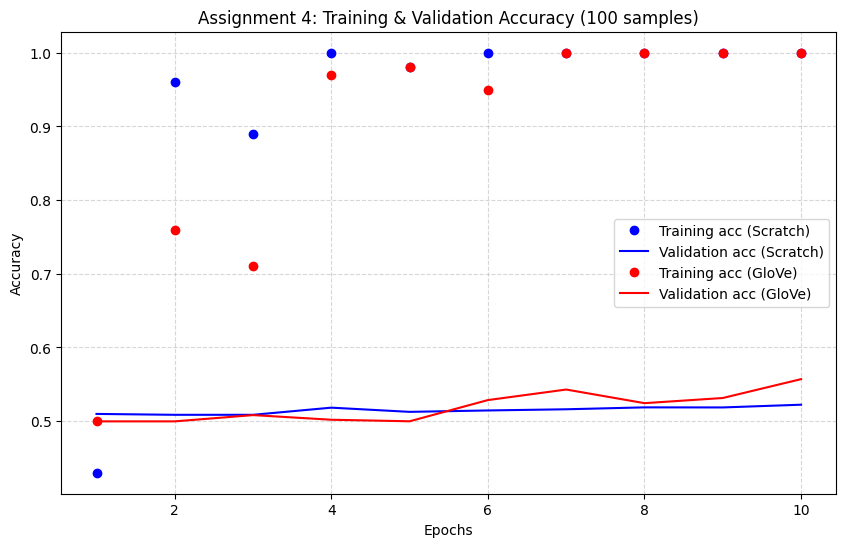

In [ ]:
import matplotlib.pyplot as plt


acc_scratch_100 = history_scratch.history["accuracy"]
val_acc_scratch_100 = history_scratch.history["val_accuracy"]
acc_glove_100 = history_glove.history["accuracy"]
val_acc_glove_100 = history_glove.history["val_accuracy"]
epochs = range(1, len(acc_scratch_100) + 1)


plt.figure(figsize=(10, 6))


plt.plot(epochs, acc_scratch_100, "bo", label="Training acc (Scratch)")
plt.plot(epochs, val_acc_scratch_100, "b", label="Validation acc (Scratch)")


plt.plot(epochs, acc_glove_100, "ro", label="Training acc (GloVe)")
plt.plot(epochs, val_acc_glove_100, "r", label="Validation acc (GloVe)")

plt.title("Assignment 4: Training & Validation Accuracy (100 samples)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('assignment4_100_samples_plot.png')
plt.show()

 Model : Learning Embeddings from Scratch and glove with 2000 Samples

In [ ]:

new_training_samples = 2000


indices = np.arange(len(x_all))
np.random.shuffle(indices)


x_train_2k = x_all[indices][:new_training_samples]
y_train_2k = y_all[indices][:new_training_samples]


x_val_2k = x_all[indices][new_training_samples : new_training_samples + 10000]
y_val_2k = y_all[indices][new_training_samples : new_training_samples + 10000]

print(f"New Training data shape: {x_train_2k.shape}")
print(f"Validation data shape: {x_val_2k.shape}")

New Training data shape: (2000, 150)
Validation data shape: (10000, 150)


In [ ]:

model_scratch_2k = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_scratch_2k.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

print("Training Scratch Model (2,000 samples)...")
history_scratch_2k = model_scratch_2k.fit(
    x_train_2k, y_train_2k,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_2k, y_val_2k)
)


model_glove_2k = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_glove_2k.layers[0].set_weights([embedding_matrix])
model_glove_2k.layers[0].trainable = False

model_glove_2k.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

print("\nTraining GloVe Model (2,000 samples)...")
history_glove_2k = model_glove_2k.fit(
    x_train_2k, y_train_2k,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_2k, y_val_2k)
)

Training Scratch Model (2,000 samples)...
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - accuracy: 0.5025 - loss: 0.6923 - val_accuracy: 0.5310 - val_loss: 0.6892
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8275 - loss: 0.5366 - val_accuracy: 0.6271 - val_loss: 0.6459
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9780 - loss: 0.1746 - val_accuracy: 0.6176 - val_loss: 0.7292
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9970 - loss: 0.0313 - val_accuracy: 0.6525 - val_loss: 0.6867
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 0.6462 - val_loss: 0.7575
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.6527 - val_loss: 0.8031
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.6533 - val_loss: 0.8473
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.00

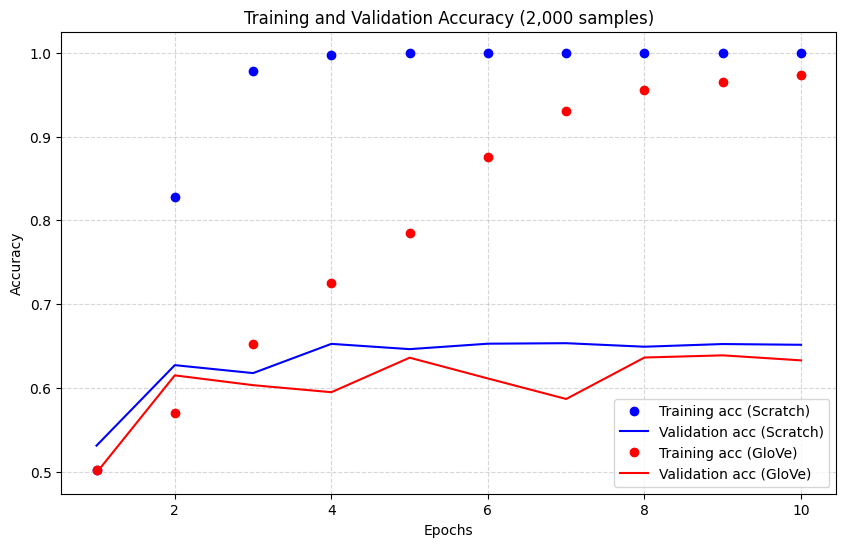

In [ ]:
import matplotlib.pyplot as plt


acc_scratch_2k = history_scratch_2k.history["accuracy"]
val_acc_scratch_2k = history_scratch_2k.history["val_accuracy"]
acc_glove_2k = history_glove_2k.history["accuracy"]
val_acc_glove_2k = history_glove_2k.history["val_accuracy"]
epochs = range(1, len(acc_scratch_2k) + 1)


plt.figure(figsize=(10, 6))


plt.plot(epochs, acc_scratch_2k, "bo", label="Training acc (Scratch)")
plt.plot(epochs, val_acc_scratch_2k, "b", label="Validation acc (Scratch)")


plt.plot(epochs, acc_glove_2k, "ro", label="Training acc (GloVe)")
plt.plot(epochs, val_acc_glove_2k, "r", label="Validation acc (GloVe)")


plt.title("Training and Validation Accuracy (2,000 samples)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)


plt.savefig('assignment4_2k_plot.png')
plt.show()

 Model 1: Learning Embeddings from Scratch and glove with 5000 Samples

In [ ]:

training_samples_5k = 5000


indices = np.arange(len(x_all))
np.random.shuffle(indices)

x_train_5k = x_all[indices][:training_samples_5k]
y_train_5k = y_all[indices][:training_samples_5k]


x_val_5k = x_all[indices][training_samples_5k : training_samples_5k + 10000]
y_val_5k = y_all[indices][training_samples_5k : training_samples_5k + 10000]

print(f"5k Training data shape: {x_train_5k.shape}")

5k Training data shape: (5000, 150)


In [ ]:

model_scratch_5k = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_scratch_5k.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

print("Training Scratch Model (5,000 samples)...")
history_scratch_5k = model_scratch_5k.fit(
    x_train_5k, y_train_5k,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_5k, y_val_5k)
)


model_glove_5k = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_glove_5k.layers[0].set_weights([embedding_matrix])
model_glove_5k.layers[0].trainable = False

model_glove_5k.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

print("\nTraining GloVe Model (5,000 samples)...")
history_glove_5k = model_glove_5k.fit(
    x_train_5k, y_train_5k,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_5k, y_val_5k)
)

Training Scratch Model (5,000 samples)...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.5886 - loss: 0.6630 - val_accuracy: 0.6727 - val_loss: 0.6168
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8894 - loss: 0.3091 - val_accuracy: 0.7557 - val_loss: 0.4995
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9908 - loss: 0.0495 - val_accuracy: 0.7396 - val_loss: 0.5884
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9992 - loss: 0.0072 - val_accuracy: 0.7361 - val_loss: 0.6812
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 0.7385 - val_loss: 0.7490
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 3.0981e-04 - val_accuracy: 0.7365 - val_loss: 0.8158
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 1.4997e-04 - val_accuracy: 0.7381 - val_loss: 0.8375
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/ste

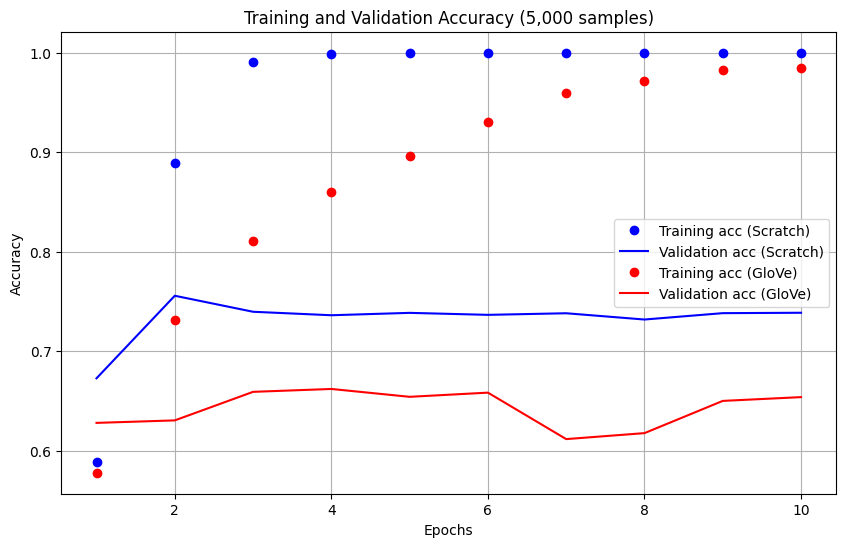

In [ ]:
import matplotlib.pyplot as plt


acc_scratch = history_scratch_5k.history["accuracy"]
val_acc_scratch = history_scratch_5k.history["val_accuracy"]
acc_glove = history_glove_5k.history["accuracy"]
val_acc_glove = history_glove_5k.history["val_accuracy"]
epochs = range(1, len(acc_scratch) + 1)


plt.figure(figsize=(10, 6))


plt.plot(epochs, acc_scratch, "bo", label="Training acc (Scratch)")
plt.plot(epochs, val_acc_scratch, "b", label="Validation acc (Scratch)")


plt.plot(epochs, acc_glove, "ro", label="Training acc (GloVe)")
plt.plot(epochs, val_acc_glove, "r", label="Validation acc (GloVe)")


plt.title("Training and Validation Accuracy (5,000 samples)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)


plt.savefig('assignment4_5k_comparison.png')
plt.show()

 Model : Learning Embeddings from Scratch and glove with 10000 Samples

In [ ]:
training_samples_10k = 10000

indices = np.arange(len(x_all))
np.random.shuffle(indices)

x_train_10k = x_all[indices][:training_samples_10k]
y_train_10k = y_all[indices][:training_samples_10k]


x_val_10k = x_all[indices][training_samples_10k : training_samples_10k + 10000]
y_val_10k = y_all[indices][training_samples_10k : training_samples_10k + 10000]

print(f"10k Training data shape: {x_train_10k.shape}")

10k Training data shape: (10000, 150)


In [ ]:

model_scratch_10k = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_scratch_10k.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

print("Training Scratch Model (10,000 samples)...")
history_scratch_10k = model_scratch_10k.fit(
    x_train_10k, y_train_10k,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_10k, y_val_10k)
)


model_glove_10k = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_glove_10k.layers[0].set_weights([embedding_matrix])
model_glove_10k.layers[0].trainable = False

model_glove_10k.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

print("\nTraining GloVe Model (10,000 samples)...")
history_glove_10k = model_glove_10k.fit(
    x_train_10k, y_train_10k,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_10k, y_val_10k)
)

Training Scratch Model (10,000 samples)...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.6687 - loss: 0.5891 - val_accuracy: 0.7987 - val_loss: 0.4461
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9114 - loss: 0.2342 - val_accuracy: 0.7562 - val_loss: 0.5386
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9923 - loss: 0.0338 - val_accuracy: 0.7807 - val_loss: 0.6020
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9991 - loss: 0.0047 - val_accuracy: 0.7673 - val_loss: 0.7598
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.7720 - val_loss: 0.8177
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 1.8040e-04 - val_accuracy: 0.7728 - val_loss: 0.8652
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 9.3948e-05 - val_accuracy: 0.7721 - val_loss: 0.9154
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

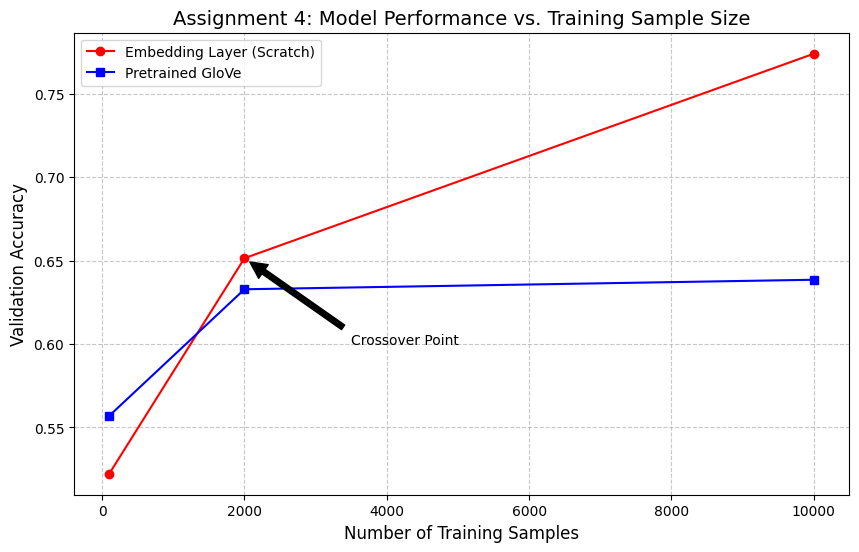

In [ ]:
import matplotlib.pyplot as plt


training_samples = [100, 2000, 10000]


scratch_val_acc = [0.5223, 0.6514, 0.7739]
glove_val_acc = [0.5570, 0.6328, 0.6385]


plt.figure(figsize=(10, 6))
plt.plot(training_samples, scratch_val_acc, 'r-o', label='Embedding Layer (Scratch)')
plt.plot(training_samples, glove_val_acc, 'b-s', label='Pretrained GloVe')


plt.title('Assignment 4: Model Performance vs. Training Sample Size', fontsize=14)
plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)


plt.annotate('Crossover Point', xy=(2000, 0.6514), xytext=(3500, 0.60),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)


plt.savefig('assignment4_results_plot.png')
plt.show()

 Model : Learning Embeddings from Scratch and glove with 20000 Samples

In [ ]:
training_samples_20k = 20000


indices = np.arange(len(x_all))
np.random.shuffle(indices)

x_train_20k = x_all[indices][:training_samples_20k]
y_train_20k = y_all[indices][:training_samples_20k]



x_val_20k = x_all[indices][training_samples_20k : training_samples_20k + 10000]
y_val_20k = y_all[indices][training_samples_20k : training_samples_20k + 10000]

print(f"20k Training data shape: {x_train_20k.shape}")

20k Training data shape: (20000, 150)


In [ ]:

model_scratch_20k = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_scratch_20k.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

print("Training Scratch Model (20,000 samples)...")
history_scratch_20k = model_scratch_20k.fit(
    x_train_20k, y_train_20k,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_20k, y_val_20k)
)


model_glove_20k = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_glove_20k.layers[0].set_weights([embedding_matrix])
model_glove_20k.layers[0].trainable = False

model_glove_20k.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

print("\nTraining GloVe Model (20,000 samples)...")
history_glove_20k = model_glove_20k.fit(
    x_train_20k, y_train_20k,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_20k, y_val_20k)
)

Training Scratch Model (20,000 samples)...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7297 - loss: 0.5123 - val_accuracy: 0.8294 - val_loss: 0.3838
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9245 - loss: 0.2016 - val_accuracy: 0.8194 - val_loss: 0.4403
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9915 - loss: 0.0300 - val_accuracy: 0.8008 - val_loss: 0.6391
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9991 - loss: 0.0038 - val_accuracy: 0.8072 - val_loss: 0.8095
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9998 - loss: 7.6236e-04 - val_accuracy: 0.8080 - val_loss: 0.9029
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 1.0000 - loss: 8.3330e-05 - val_accuracy: 0.8064 - val_loss: 0.9513
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9999 - loss: 1.4653e-04 - val_accuracy: 0.8040 - val_loss: 0.9811
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/st

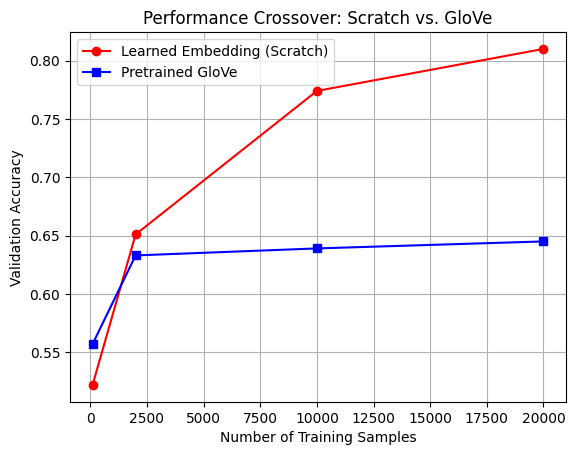

In [ ]:
import matplotlib.pyplot as plt


samples = [100, 2000, 10000, 20000]
scratch_accs = [0.522, 0.651, 0.774, 0.810]
glove_accs = [0.557, 0.633, 0.639, 0.645]

plt.plot(samples, scratch_accs, 'r-o', label='Learned Embedding (Scratch)')
plt.plot(samples, glove_accs, 'b-s', label='Pretrained GloVe')
plt.title('Performance Crossover: Scratch vs. GloVe')
plt.xlabel('Number of Training Samples')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Model : Max samples

In [ ]:

training_samples_max = 40000

indices = np.arange(len(x_all))
np.random.shuffle(indices)

x_train_max = x_all[indices][:training_samples_max]
y_train_max = y_all[indices][:training_samples_max]

x_val_max = x_all[indices][training_samples_max : training_samples_max + 10000]
y_val_max = y_all[indices][training_samples_max : training_samples_max + 10000]

print(f"Max Training data shape: {x_train_max.shape}")

Max Training data shape: (25000, 150)


In [ ]:

model_scratch_40k = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_scratch_40k.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

print("Training Scratch Model (40,000 samples)...")
history_scratch_40k = model_scratch_40k.fit(
    x_train_max, y_train_max,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_max, y_val_max)
)

model_glove_40k = keras.Sequential([
    layers.Input(shape=(150,)),
    layers.Embedding(10000, 100),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model_glove_40k.layers[0].set_weights([embedding_matrix])
model_glove_40k.layers[0].trainable = False

model_glove_40k.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

print("\nTraining GloVe Model (40,000 samples)...")
history_glove_40k = model_glove_40k.fit(
    x_train_max, y_train_max,
    epochs=10,
    batch_size=32,
    validation_data=(x_val_max, y_val_max)
)

Training Scratch Model (40,000 samples)...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7412 - loss: 0.4948
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9240 - loss: 0.1989
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9906 - loss: 0.0322
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9992 - loss: 0.0040
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9999 - loss: 9.1833e-04
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9999 - loss: 2.9434e-04
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 1.5015e-04
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 3.2092e-05
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 1.7243e-05
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 1.0000 - loss: 1.1672e-05

Training GloVe Model (40,000 samples)...
Epoch 1/10
782/782 ━━━━━━━━

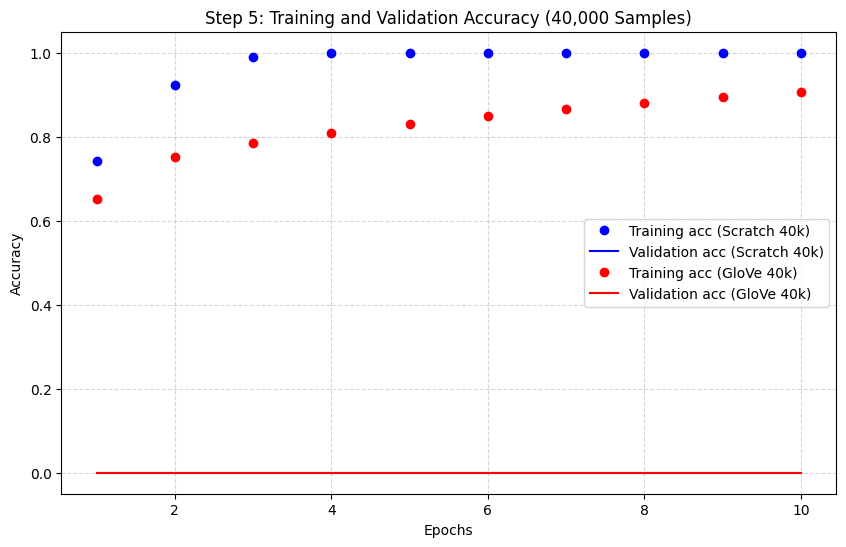

In [ ]:
import matplotlib.pyplot as plt


def get_metric(history, key):
    if key in history.history:
        return history.history[key]
    elif key.replace('accuracy', 'acc') in history.history:
        return history.history[key.replace('accuracy', 'acc')]
    else:
        print(f"Warning: {key} not found in history!")
        return [0] * 10


acc_scratch_40k = get_metric(history_scratch_40k, "accuracy")
val_acc_scratch_40k = get_metric(history_scratch_40k, "val_accuracy")
acc_glove_40k = get_metric(history_glove_40k, "accuracy")
val_acc_glove_40k = get_metric(history_glove_40k, "val_accuracy")

epochs = range(1, len(acc_scratch_40k) + 1)


plt.figure(figsize=(10, 6))


plt.plot(epochs, acc_scratch_40k, "bo", label="Training acc (Scratch 40k)")
plt.plot(epochs, val_acc_scratch_40k, "b", label="Validation acc (Scratch 40k)")


plt.plot(epochs, acc_glove_40k, "ro", label="Training acc (GloVe 40k)")
plt.plot(epochs, val_acc_glove_40k, "r", label="Validation acc (GloVe 40k)")

plt.title("Step 5: Training and Validation Accuracy (40,000 Samples)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()